# Introduction
This project aims to build a recurrent neural network (RNN) for predicting PM2.5 air pollution levels in Beijing using time-series analysis.

# 1. Configuration

In [1]:
# Install libraries
# %pip install numpy pandas matplotlib seaborn statsmodels scikit-learn tensorflow keras IPython pydot graphviz

In [2]:
# Import libraries
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from IPython.display import Image
from sklearn.metrics import mean_squared_error, r2_score
import pydot
import graphviz

2026-01-16 15:42:09.818427: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# Add project directory to sys.path 
project_path = Path().resolve().parent  
sys.path.append(str(project_path))

# 2. Data Loading and Preprocessing

In [4]:
# Load data
df = pd.read_csv('../data/PRSA_Data_Wanshouxigong_20130301-20170228.csv',
                 usecols=lambda column : column not in ['No', 'wd', 'station'])

In [5]:
# Preprocess date and set as index, display dataframe
df['Date'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df.set_index('Date', inplace=True)
df.drop(columns=['year', 'month', 'day', 'hour'], inplace=True)
df

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
Date,,,,,,,,,,,
2013-03-01 00:00:00,9.0,9.0,6.0,17.0,200.0,62.0,0.3,1021.9,-19.0,0.0,2.0
2013-03-01 01:00:00,11.0,11.0,7.0,14.0,200.0,66.0,-0.1,1022.4,-19.3,0.0,4.4
2013-03-01 02:00:00,8.0,8.0,NaN,16.0,200.0,59.0,-0.6,1022.6,-19.7,0.0,4.7
2013-03-01 03:00:00,8.0,8.0,3.0,16.0,NaN,NaN,-0.7,1023.5,-20.9,0.0,2.6
2013-03-01 04:00:00,8.0,8.0,3.0,NaN,300.0,36.0,-0.9,1024.1,-21.7,0.0,2.5
...,...,...,...,...,...,...,...,...,...,...,...
2017-02-28 19:00:00,11.0,32.0,3.0,24.0,400.0,72.0,12.5,1013.5,-16.2,0.0,2.4
2017-02-28 20:00:00,13.0,32.0,3.0,41.0,500.0,50.0,11.6,1013.6,-15.1,0.0,0.9
2017-02-28 21:00:00,14.0,28.0,4.0,38.0,500.0,54.0,10.8,1014.2,-13.3,0.0,1.1


In [6]:
# Display dataframe info
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 35064 entries, 2013-03-01 00:00:00 to 2017-02-28 23:00:00
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   PM2.5   34368 non-null  float64
 1   PM10    34580 non-null  float64
 2   SO2     34395 non-null  float64
 3   NO2     34310 non-null  float64
 4   CO      33767 non-null  float64
 5   O3      33986 non-null  float64
 6   TEMP    35045 non-null  float64
 7   PRES    35045 non-null  float64
 8   DEWP    35045 non-null  float64
 9   RAIN    35045 non-null  float64
 10  WSPM    35051 non-null  float64
dtypes: float64(11)
memory usage: 3.2 MB


## 2.1. Data Interpretation

* PM2.5 (μg/m3) - concentration of suspended particulate matter in the air with a diameter of no more than 2.5 μm. According to the WHO, it is the most harmful atmospheric pollutant to humans.

* PM10 (μg/m3) - concentration of so-called "coarse particulate matter," i.e., suspended particulate matter in the air with a diameter of no more than 10 μm. Its occurrence is associated with, among other things, fuel combustion processes
* SO2, NO2, CO, O3 (μg/m3) - concentration of sulfur dioxide, nitrogen dioxide, carbon monoxide, and ozone
* TEMP (degrees C) - air temperature
* PRES (hPa) - air pressure
* DEWP (degrees C) - dew point temperature - the temperature at which water vapor in the air reaches saturation, resulting in the formation of fog, clouds, precipitation, and latent precipitation
* RAIN (mm) - precipitation
* WSPM (m/s) - wind speed

## 2.2. Handling Missing Values

In [7]:
# Display dataframe statistics
df.describe()

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,34368.000000,34580.000000,34395.000000,34310.00000,33767.000000,33986.000000,35045.000000,35045.000000,35045.000000,35045.000000,35051.000000
mean,85.024136,112.223459,17.148603,55.52956,1370.395031,56.229904,13.784477,1011.511804,2.707442,0.064320,1.745314
std,85.975981,97.593210,23.940834,35.80805,1223.139114,57.082710,11.385156,10.570928,13.704139,0.796981,1.206355
min,3.000000,2.000000,0.285600,2.00000,100.000000,0.214200,-16.800000,985.100000,-35.300000,0.000000,0.000000
25%,23.000000,39.000000,3.000000,28.00000,600.000000,8.000000,3.400000,1002.800000,-8.500000,0.000000,0.900000
50%,60.000000,91.000000,8.000000,49.00000,1000.000000,42.000000,14.800000,1011.000000,3.300000,0.000000,1.400000
75%,116.000000,154.000000,21.000000,77.00000,1700.000000,82.000000,23.500000,1020.000000,15.200000,0.000000,2.300000
max,999.000000,961.000000,411.000000,251.00000,9800.000000,358.000000,40.600000,1042.000000,28.500000,46.400000,13.200000


In [8]:
# Check for missing and duplicated values
df.isna().sum(), df.duplicated().sum()

(PM2.5     696
 PM10      484
 SO2       669
 NO2       754
 CO       1297
 O3       1078
 TEMP       19
 PRES       19
 DEWP       19
 RAIN       19
 WSPM       13
 dtype: int64,
 0)

In [9]:
# Handle missing values with time-based interpolation
for column in df.columns:
    if column != 'PM2.5':
        df[column] = df[column].interpolate(method='time')

In [10]:
# Drop rows with missing PM2.5 values
df.dropna(subset=['PM2.5'], inplace=True)

## 2.3. Exploratory Data Analysis

In [11]:
# Display updated dataframe statistics including skewness and kurtosis
df_desc = df.describe()
df_desc.loc['skew'] = df.skew()
df_desc.loc['kurtosis'] = df.kurt()
df_desc

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,34368.000000,34368.000000,34368.000000,34368.000000,34368.000000,34368.000000,34368.000000,34368.000000,34368.000000,34368.000000,34368.000000
mean,85.024136,112.439121,17.327185,55.542124,1374.438353,55.446042,13.730478,1011.538130,2.677686,0.063955,1.743690
std,85.975981,98.050989,24.123297,35.764414,1228.343412,56.868467,11.376962,10.569808,13.729979,0.782207,1.205465
min,3.000000,2.000000,0.285600,2.000000,100.000000,0.214200,-16.800000,985.100000,-35.300000,0.000000,0.000000
25%,23.000000,39.000000,3.000000,28.000000,600.000000,8.000000,3.400000,1002.900000,-8.500000,0.000000,0.900000
50%,60.000000,91.000000,8.000000,49.000000,1000.000000,41.000000,14.700000,1011.000000,3.300000,0.000000,1.400000
75%,116.000000,154.000000,21.000000,77.000000,1700.000000,81.000000,23.400000,1020.000000,15.300000,0.000000,2.300000
max,999.000000,961.000000,411.000000,251.000000,9800.000000,358.000000,40.600000,1042.000000,28.500000,46.400000,13.200000
skew,2.101823,1.896607,2.916257,0.970030,2.434251,1.422533,-0.103337,0.119676,-0.197021,26.355780,1.533398
kurtosis,6.698026,6.023426,12.823400,0.891796,8.211802,1.960097,-1.159705,-0.875896,-1.106550,953.499157,3.307776


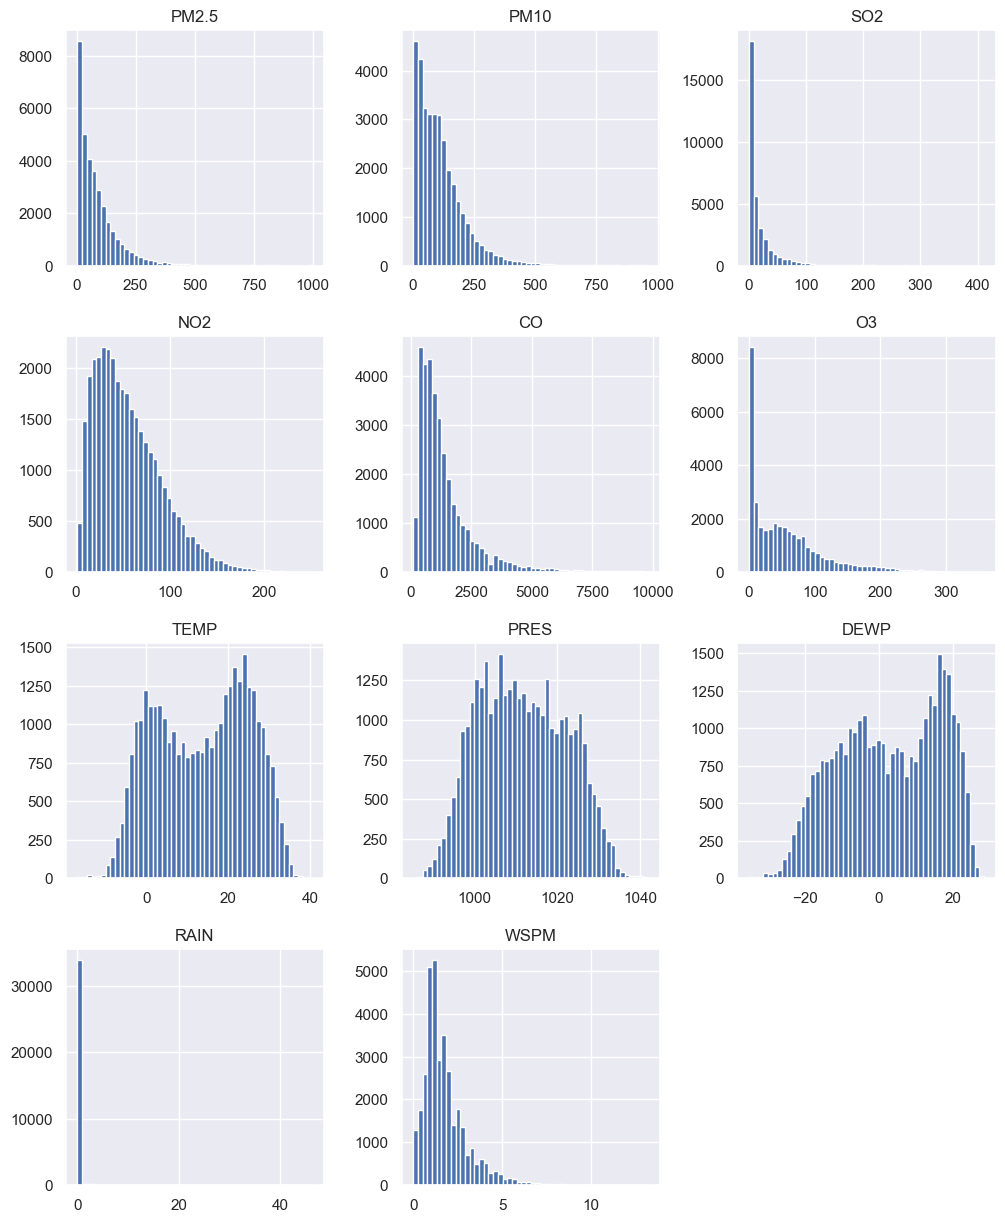

In [12]:
# Visualize data distributions
df.hist(bins=50, figsize=(12, 15));

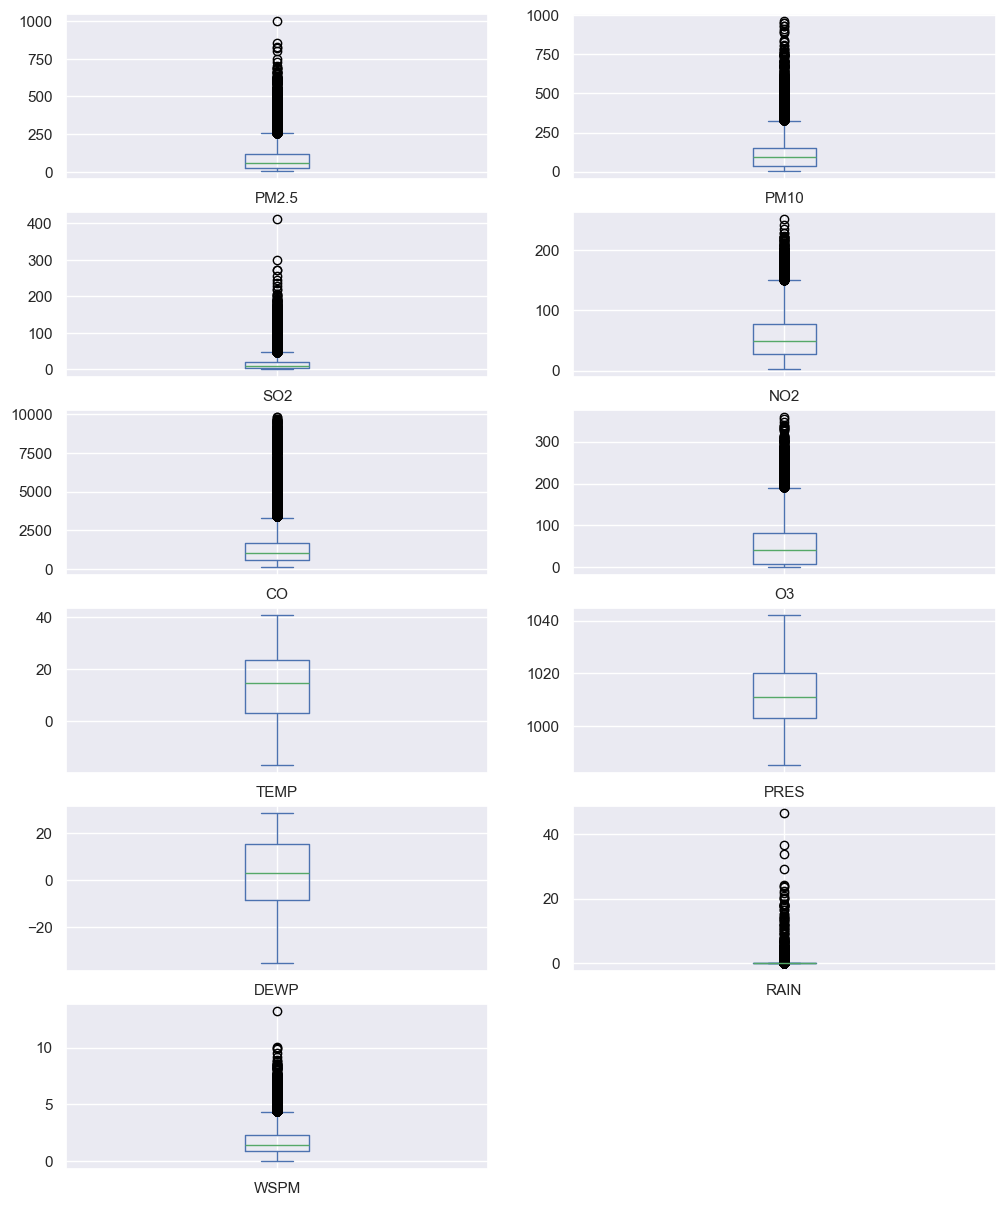

In [13]:
# Visualize box plots for outlier detection
df.plot(kind='box', subplots=True, layout=(6, 2), figsize=(12, 15), sharex=False, sharey=False);

Observations:
* Analysis of skewness levels, histograms, and box plots indicates that all 5 variables describing air pollution levels have distributions with high positive skewness, meaning there are a large number of outliers on the right side of the distributions.

* This indicates that during the observation period, many measurements were taken when air pollution levels were very high.
* The 999 level of the PM2.5 variable represents the maximum possible measurement by the sensors.
* The distribution of the O3 variable is similar.
* The distributions of the TEMP, PRES, and DEWP variables are relatively symmetrical, with no outliers.
* For the RAIN variable, the most common value was 0 (at least 75% of observations).
* The mean value of the WSPM variable is not large, although a significant number of outliers were also observed.

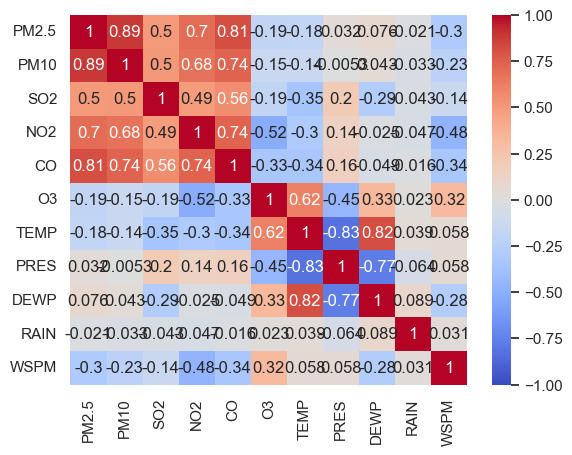

In [14]:
# Visualize correlation heatmap
plt.figure()#figsize=(12, 10))
sns.heatmap(df.corr(), vmin=-1, vmax=1, cmap='coolwarm', annot=True);

Observations:
* the variables PM2.5, PM10, NO2, and CO2 are strongly correlated with each other,

* the variable SO2 is slightly less correlated with the other variables describing the level of air pollution,
* the variables O3, TEMP, and WSPM show a weak, negative correlation with the target variable,
* the variables PRES, DEWP, and RAIN are very weakly correlated with the target variable, including the variable RAIN showing virtually no correlation with any of the other variables,
* therefore, the variables PRES, DEWP, and RAIN can be considered irrelevant to the model's predictive ability and removed from the dataset,
* a strong positive correlation can also be observed between the variables TEMP and O3, and TEMP and DEWP (dew point temperature is always lower than air temperature),
* the variables TEMP and DEWP show a strong negative correlation with the variable PRES.


In [15]:
# Drop irrelevant columns
df = df.drop(columns=['PRES', 'DEWP', 'RAIN'])

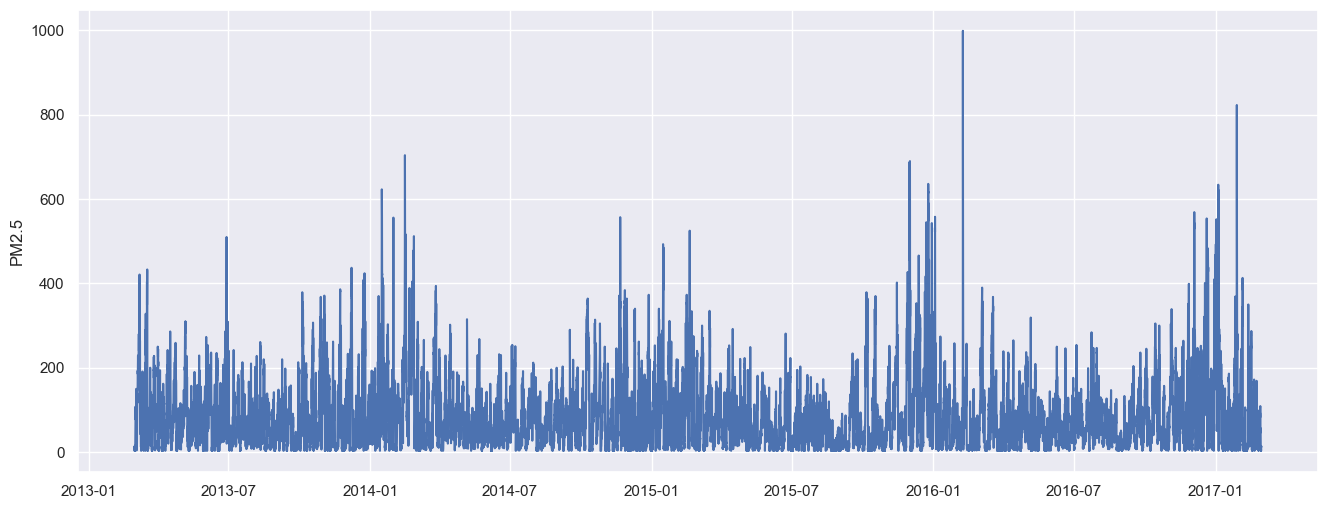

In [16]:
# Visualize target variable PM2.5 time series
plt.figure(figsize=(16, 6))
plt.plot(df.index, df['PM2.5'])
plt.ylabel("PM2.5");

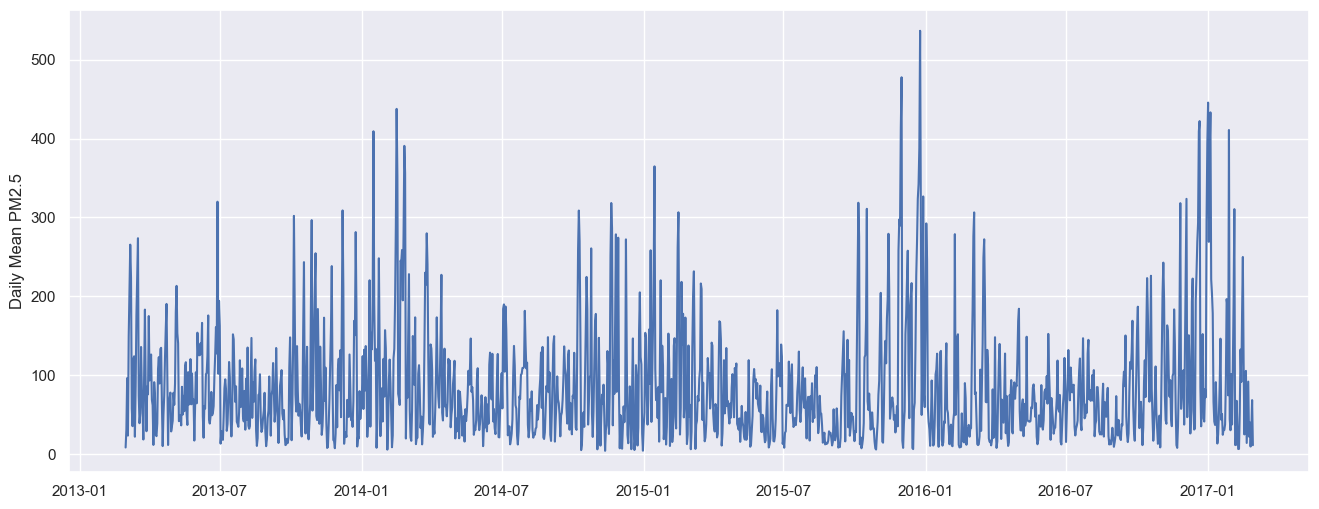

In [17]:
# Visualize daily mean PM2.5
daily_mean = df.groupby(df.index.date)['PM2.5'].mean()
plt.figure(figsize=(16, 6))
plt.plot(daily_mean.index, daily_mean)
plt.ylabel("Daily Mean PM2.5");

Observations:
- the average value of the variable in the period under review was 85, which, according to standards, indicates poor air quality,

- the graph clearly shows increases around January each year, i.e., during the winter period,
- in the remaining months, especially summer, pollution levels are lower and relatively constant,
- no clear upward or downward trend is visible when comparing year-over-year data.

## 2.4. Preparing Features and Target Variable for Training

In [18]:
# Split data into features and target variable
X = df.drop(columns=['PM2.5'])
y = df['PM2.5']

In [19]:
# Standardize features and target variable
scaler_X = StandardScaler()
X = scaler_X.fit_transform(X)

scaler_y = StandardScaler()
y = scaler_y.fit_transform(y.values.reshape(-1, 1))

In [20]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, shuffle=False)

In [21]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((30931, 7), (3437, 7), (30931, 1), (3437, 1))

In [22]:
# Create time series generators
n_window = 24
n_features = X_train.shape[1]
batch_size = 64

gen_train = TimeseriesGenerator(X_train, y_train, length=n_window, batch_size=batch_size)
gen_test = TimeseriesGenerator(X_test, y_test, length=n_window, batch_size=batch_size)
len(gen_train), len(gen_test)

(483, 54)

# 3. RNN Model Building and Compilation

In [23]:
# Build RNN model
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(n_window, n_features)),
    Dropout(0.2),
    LSTM(32, return_sequences=True),
    Dropout(0.2),
    LSTM(8),
    Dropout(0.2),
    Dense(1, activation='linear')
])

model.summary()

/Users/przwar/Desktop/Moje/AI/Projects/air-quality-rnn/.venv/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 24, 32)         │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 8)              │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 91,561 (357.66 KB)

 Trainable params: 91,561 (357.66 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['R2Score'])

# 4. Model Training

In [26]:
# Train the model with early stopping
fit = model.fit(gen_train, validation_data=gen_test, epochs=50,
          callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)])

Epoch 1/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 44s 77ms/step - R2Score: 0.5596 - loss: 0.3915 - val_R2Score: 0.7890 - val_loss: 0.3984
Epoch 2/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 31s 65ms/step - R2Score: 0.7198 - loss: 0.2491 - val_R2Score: 0.8443 - val_loss: 0.2940
Epoch 3/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 32s 66ms/step - R2Score: 0.7691 - loss: 0.2053 - val_R2Score: 0.8819 - val_loss: 0.2230
Epoch 4/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 34s 70ms/step - R2Score: 0.7890 - loss: 0.1876 - val_R2Score: 0.7951 - val_loss: 0.3869
Epoch 5/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 28s 57ms/step - R2Score: 0.8080 - loss: 0.1707 - val_R2Score: 0.8826 - val_loss: 0.2217
Epoch 6/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 25s 52ms/step - R2Score: 0.8098 - loss: 0.1691 - val_R2Score: 0.9089 - val_loss: 0.1721
Epoch 7/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 31s 64ms/step - R2Score: 0.8158 - loss: 0.1637 - val_R2Score: 0.9057 - val_loss: 0.1780
Epoch 8/50
483/483 ━━━━━━━━━━━━━━━━━━━━ 25s 52ms/step - R2Score: 0.8156 - loss: 0.1640 - val_R2Score: 0.

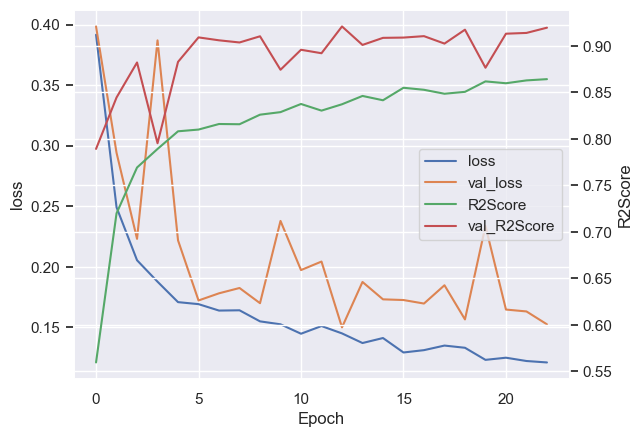

In [27]:
from src.visualization import plot_training_history

# Visualize training process
plot_training_history(fit.history, metric='R2Score')

The following parameters were adjusted in the training process to minimize the loss function:
- The batch size was kept at 64, although at the cost of extending the training process relative to higher values ​​of this parameter.

- Due to the clear tendency of the model to overfit, Dropout layers (0.2) were added after each LSTM layer.
- Despite adding Dropout layers, the model still tends to overfit, especially in the loss function, which is stopped at the appropriate moment using the EarlyStopping function.
- This is clearly visible in the graph illustrating the changes in MSE and R2Score over epochs.
- Two different optimization algorithms were used during model compilation – Adam and Rmsprop – however, no significant differences were observed during training, and the model achieved similar results.
- Similarly, adding subsequent LSTM and Dropout layers did not appear to have a significant, positive impact on the model's results.
- Ultimately, the model achieved an R2 of 0.91 for the test set.

# 5. Model Evaluation

In [28]:
# Reverse scale target variable
y_train = scaler_y.inverse_transform(y_train)
y_test = scaler_y.inverse_transform(y_test)

In [29]:
# Make predictions
y_pred_train = model.predict(gen_train)
y_pred_test = model.predict(gen_test)

483/483 ━━━━━━━━━━━━━━━━━━━━ 13s 25ms/step
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


In [30]:
# Reverse scale predictions
y_pred_train = scaler_y.inverse_transform(y_pred_train)
y_pred_test = scaler_y.inverse_transform(y_pred_test)

In [31]:
# Compare shapes of true and predicted values
y_train.shape, y_test.shape, y_pred_train.shape, y_pred_test.shape

((30931, 1), (3437, 1), (30907, 1), (3413, 1))

In [32]:
# Calculate MSE and R2 score
mse_train = mean_squared_error(y_train[n_window:], y_pred_train)
mse_test = mean_squared_error(y_test[n_window:], y_pred_test)

r2_train = r2_score(y_train[n_window:], y_pred_train)
r2_test = r2_score(y_test[n_window:], y_pred_test)
mse_train, mse_test, r2_train, r2_test

(769.4316896165434, 1107.8123609089464, 0.8829084203838355, 0.9206396220756983)

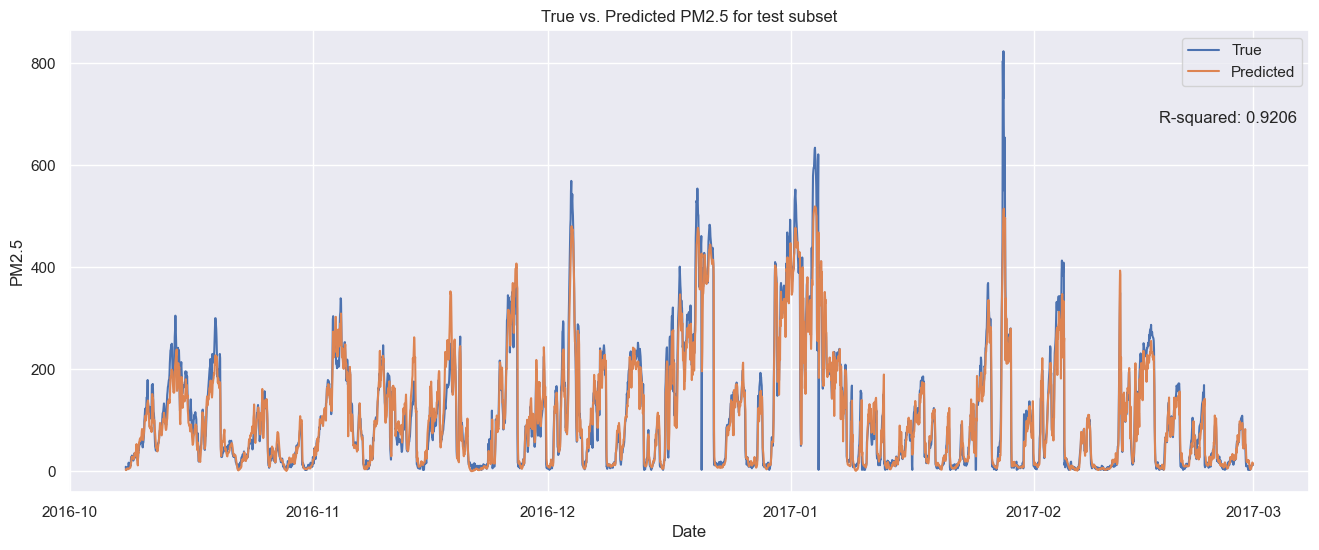

In [33]:
# Visualize results for test subset
test_dates = df.index[-len(y_test):]

plot_df = pd.DataFrame({'True': y_test[n_window:].flatten(),
                        'Predicted': y_pred_test.flatten()}, index=test_dates[n_window:])

plt.figure(figsize=(16, 6))
plt.plot(plot_df['True'], label='True')
plt.plot(plot_df['Predicted'], label='Predicted')
plt.xlabel('Date')
plt.ylabel('PM2.5')
plt.title('True vs. Predicted PM2.5 for test subset')
plt.legend(loc='upper right')
plt.grid(True)
plt.text(0.99, 0.8, f'R-squared: {r2_test:.4f}',
         transform=plt.gca().transAxes, ha='right', fontsize=12)
plt.show()